In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Load the dataset
df = pd.read_excel("../data/raw/FoodCompositionTable.xlsx")

df.head()

,S.N.,Food Commodity,Edible Portion,Moisture (g),Protein (g),Fat (g),Carbohydrate (g),Minerals (g),Fiber (g),Energy (KCal),Calcium (mg),Phosphorus (mg),Iron (mg),Carotene (µg),Vitamin C (mg),Thiamine (mg),Riboflavin (mg),Niacin (mg)
0,1,Amaranth seed,100,10.6,9.4,7.17,68.1,2.6,2.2,375,37,529.1,5.2,-,-,-,-,-
1,2,Barely,100,12.5,11.5,1.3,69.6,1.2,3.9,336,26,215,1.7,10,0,0.47,0.2,5.4
2,3,Buck wheat (whole),74,11.3,10.3,2.4,65.1,2.3,8.6,323,64,355,15.5,0,0,0.9,0.34,4.4
3,4,Bajra,84,12.4,11.6,5,67.5,2.3,1.2,361,42,296,8,132,0,0.33,0.25,2.3
4,5,Bamboo seed,100,7.8,13.1,1.1,75.9,1.1,0.9,367,37,162,6.4,-,-,0.17,0.12,1.1


In [3]:
#Dataset Dimensions
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 631
Columns: 18


In [4]:
#Column names
print(df.columns.tolist())

['S.N.', 'Food Commodity', 'Edible Portion', 'Moisture (g)', 'Protein (g)', 'Fat (g)', 'Carbohydrate (g)', 'Minerals (g)', 'Fiber (g)', 'Energy (KCal)', 'Calcium (mg)', 'Phosphorus (mg)', 'Iron (mg)', 'Carotene (µg)', 'Vitamin C (mg)', 'Thiamine (mg)', 'Riboflavin (mg)', 'Niacin (mg)']


In [5]:
#Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   S.N.              631 non-null    object
 1   Food Commodity    628 non-null    str   
 2   Edible Portion    627 non-null    object
 3   Moisture (g)      628 non-null    object
 4   Protein (g)       628 non-null    object
 5   Fat (g)           626 non-null    object
 6   Carbohydrate (g)  628 non-null    object
 7   Minerals (g)      628 non-null    object
 8   Fiber (g)         626 non-null    object
 9   Energy (KCal)     628 non-null    object
 10  Calcium (mg)      628 non-null    object
 11  Phosphorus (mg)   628 non-null    object
 12  Iron (mg)         628 non-null    object
 13  Carotene (µg)     626 non-null    object
 14  Vitamin C (mg)    626 non-null    object
 15  Thiamine (mg)     628 non-null    object
 16  Riboflavin (mg)   627 non-null    object
 17  Niacin (mg)       626 non-n

In [6]:
#statistical Summary
df.describe(include="all").T

,count,unique,top,freq
S.N.,631,624,326,2
Food Commodity,628,620,Garlic dry,2
Edible Portion,627,63,-,265
Moisture (g),628,425,–,16
Protein (g),628.0,305.0,0.7,19.0
Fat (g),626.0,247.0,0.1,61.0
Carbohydrate (g),628,394,–,25
Minerals (g),628.0,204.0,0.6,27.0
Fiber (g),626,186,-,76
Energy (KCal),628,343,900,13


In [7]:
#Missing values
missing = df.isnull().sum()

print(missing)

S.N.                0
Food Commodity      3
Edible Portion      4
Moisture (g)        3
Protein (g)         3
Fat (g)             5
Carbohydrate (g)    3
Minerals (g)        3
Fiber (g)           5
Energy (KCal)       3
Calcium (mg)        3
Phosphorus (mg)     3
Iron (mg)           3
Carotene (µg)       5
Vitamin C (mg)      5
Thiamine (mg)       3
Riboflavin (mg)     4
Niacin (mg)         5
dtype: int64


In [8]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(
    missing_percentage.sort_values(ascending=False)
)

Niacin (mg)         0.792393
Fat (g)             0.792393
Vitamin C (mg)      0.792393
Carotene (µg)       0.792393
Fiber (g)           0.792393
Edible Portion      0.633914
Riboflavin (mg)     0.633914
Phosphorus (mg)     0.475436
Thiamine (mg)       0.475436
Iron (mg)           0.475436
Energy (KCal)       0.475436
Calcium (mg)        0.475436
Food Commodity      0.475436
Minerals (g)        0.475436
Carbohydrate (g)    0.475436
Protein (g)         0.475436
Moisture (g)        0.475436
S.N.                0.000000
dtype: float64


In [9]:
#Check the - values
dash_counts = (df == "-").sum()

print(dash_counts[dash_counts > 0])

Edible Portion      265
Moisture (g)          4
Protein (g)           4
Fat (g)               5
Carbohydrate (g)     10
Minerals (g)         12
Fiber (g)            76
Energy (KCal)         9
Calcium (mg)         91
Phosphorus (mg)     121
Iron (mg)           134
Carotene (µg)       285
Vitamin C (mg)      237
Thiamine (mg)       310
Riboflavin (mg)     314
Niacin (mg)         311
dtype: int64


In [10]:
#Duplicate foods
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 6


In [11]:
print(
    "Duplicate food names:",
    df["Food Commodity"].duplicated().sum()
)

Duplicate food names: 10


In [12]:
#Unique food count
print("Unique food items:", df["Food Commodity"].nunique())

Unique food items: 620


In [13]:
#Numeric Columns
numeric_columns = df.select_dtypes(include=np.number).columns

print(numeric_columns.tolist())

[]


In [17]:
df.dtypes

S.N.                object
Food Commodity         str
Edible Portion      object
Moisture (g)        object
Protein (g)         object
Fat (g)             object
Carbohydrate (g)    object
Minerals (g)        object
Fiber (g)           object
Energy (KCal)       object
Calcium (mg)        object
Phosphorus (mg)     object
Iron (mg)           object
Carotene (µg)       object
Vitamin C (mg)      object
Thiamine (mg)       object
Riboflavin (mg)     object
Niacin (mg)         object
dtype: object

In [23]:
numeric_columns = [
    "Edible Portion",
    "Moisture (g)",
    "Protein (g)",
    "Fat (g)",
    "Carbohydrate (g)",
    "Minerals (g)",
    "Fiber (g)",
    "Energy (KCal)",
    "Calcium (mg)",
    "Phosphorus (mg)",
    "Iron (mg)",
    "Carotene (µg)",
    "Vitamin C (mg)",
    "Thiamine (mg)",
    "Riboflavin (mg)",
    "Niacin (mg)"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [24]:
df[numeric_columns].dtypes

Edible Portion      float64
Moisture (g)        float64
Protein (g)         float64
Fat (g)             float64
Carbohydrate (g)    float64
Minerals (g)        float64
Fiber (g)           float64
Energy (KCal)       float64
Calcium (mg)        float64
Phosphorus (mg)     float64
Iron (mg)           float64
Carotene (µg)       float64
Vitamin C (mg)      float64
Thiamine (mg)       float64
Riboflavin (mg)     float64
Niacin (mg)         float64
dtype: object

In [25]:
print(df.select_dtypes(include="number").columns.tolist())

['Edible Portion', 'Moisture (g)', 'Protein (g)', 'Fat (g)', 'Carbohydrate (g)', 'Minerals (g)', 'Fiber (g)', 'Energy (KCal)', 'Calcium (mg)', 'Phosphorus (mg)', 'Iron (mg)', 'Carotene (µg)', 'Vitamin C (mg)', 'Thiamine (mg)', 'Riboflavin (mg)', 'Niacin (mg)']


In [26]:
#Check extreme values
df[numeric_columns].describe().T[
    ["min", "max", "mean", "std"]
]

,min,max,mean,std
Edible Portion,30.000,100.0,89.508316,16.385128
Moisture (g),0.400,97.7,51.835461,35.959943
Protein (g),0.000,70.8,8.645263,9.494671
Fat (g),0.000,100.0,7.760187,17.982903
Carbohydrate (g),0.000,346.0,30.701417,29.877103
Minerals (g),0.100,21.1,2.121644,2.273672
Fiber (g),0.000,330.0,3.491520,15.639546
Energy (KCal),2.600,900.0,215.620602,194.310054
Calcium (mg),2.440,3095.0,153.367475,319.765922
Phosphorus (mg),0.260,1410.0,167.870064,179.586208


In [27]:
df[numeric_columns].isnull().sum()

Edible Portion      334
Moisture (g)         23
Protein (g)          23
Fat (g)              28
Carbohydrate (g)     38
Minerals (g)         41
Fiber (g)           160
Energy (KCal)        16
Calcium (mg)        136
Phosphorus (mg)     165
Iron (mg)           192
Carotene (µg)       376
Vitamin C (mg)      329
Thiamine (mg)       409
Riboflavin (mg)     414
Niacin (mg)         407
dtype: int64

In [28]:
df[numeric_columns].isnull().sum().sort_values(ascending=False)

Riboflavin (mg)     414
Thiamine (mg)       409
Niacin (mg)         407
Carotene (µg)       376
Edible Portion      334
Vitamin C (mg)      329
Iron (mg)           192
Phosphorus (mg)     165
Fiber (g)           160
Calcium (mg)        136
Minerals (g)         41
Carbohydrate (g)     38
Fat (g)              28
Moisture (g)         23
Protein (g)          23
Energy (KCal)        16
dtype: int64

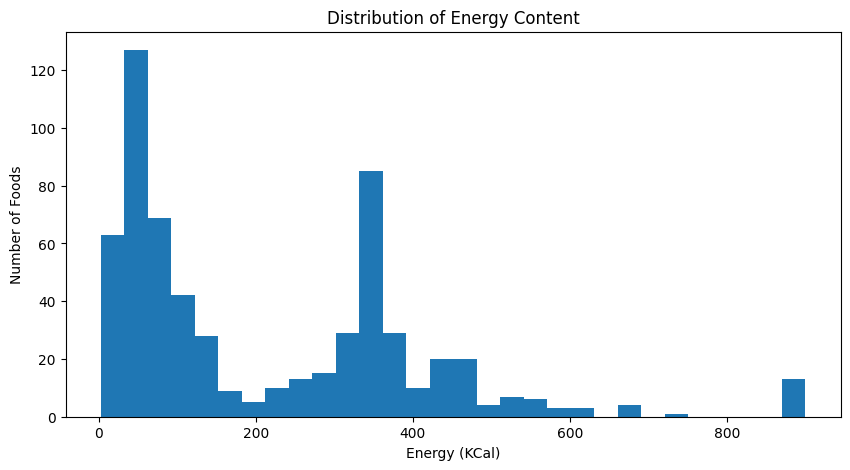

In [29]:
#Energy Distribution
plt.figure(figsize=(10, 5))

plt.hist(df["Energy (KCal)"], bins=30)

plt.xlabel("Energy (KCal)")
plt.ylabel("Number of Foods")
plt.title("Distribution of Energy Content")

plt.show()

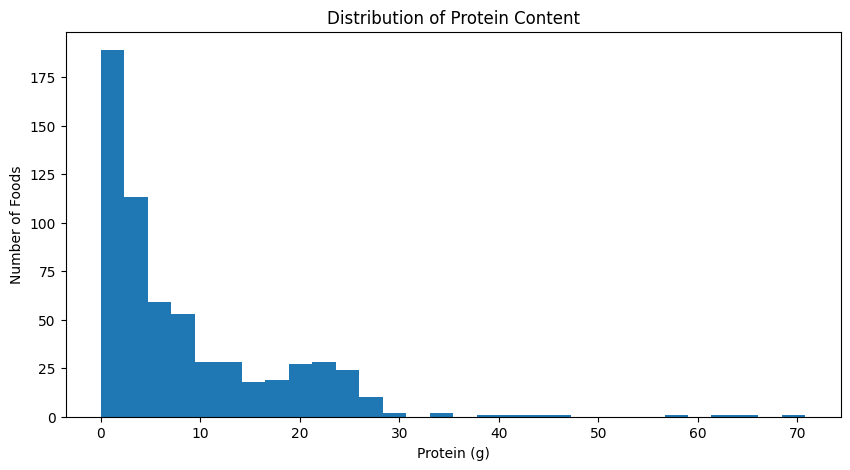

In [30]:
#Protein distribution
plt.figure(figsize=(10, 5))

plt.hist(df["Protein (g)"], bins=30)

plt.xlabel("Protein (g)")
plt.ylabel("Number of Foods")
plt.title("Distribution of Protein Content")

plt.show()

In [31]:
#Correlation Analysis
nutrition_columns = [
    "Moisture (g)",
    "Protein (g)",
    "Fat (g)",
    "Carbohydrate (g)",
    "Minerals (g)",
    "Fiber (g)",
    "Energy (KCal)",
    "Calcium (mg)",
    "Phosphorus (mg)",
    "Iron (mg)",
    "Carotene (µg)",
    "Vitamin C (mg)",
    "Thiamine (mg)",
    "Riboflavin (mg)",
    "Niacin (mg)"
]

correlation = df[nutrition_columns].corr()

correlation

,Moisture (g),Protein (g),Fat (g),Carbohydrate (g),Minerals (g),Fiber (g),Energy (KCal),Calcium (mg),Phosphorus (mg),Iron (mg),Carotene (µg),Vitamin C (mg),Thiamine (mg),Riboflavin (mg),Niacin (mg)
Moisture (g),1.000000,-0.589278,-0.429704,-0.772726,-0.478837,-0.144640,-0.931133,-0.128260,-0.560027,-0.231465,0.208029,0.067291,-0.561525,-0.157627,-0.090889
Protein (g),-0.589278,1.000000,0.305648,0.273834,0.501693,0.083502,0.585356,0.228207,0.768715,0.129590,-0.089723,-0.039789,0.569387,0.274280,0.115572
Fat (g),-0.429704,0.305648,1.000000,0.032621,0.214707,0.026880,0.758032,0.058024,0.382329,0.053416,-0.005554,-0.034082,0.275933,0.067288,0.103251
Carbohydrate (g),-0.772726,0.273834,0.032621,1.000000,0.223140,0.089937,0.665638,-0.043692,0.252076,0.122092,-0.215517,-0.065229,0.405203,0.043877,0.044496
Minerals (g),-0.478837,0.501693,0.214707,0.223140,1.000000,0.146755,0.376649,0.596155,0.536098,0.420353,0.113618,-0.023014,0.567148,0.374692,0.139435
Fiber (g),-0.144640,0.083502,0.026880,0.089937,0.146755,1.000000,0.024798,0.127626,0.026874,0.228960,-0.084672,-0.024025,0.259234,0.220281,0.044821
Energy (KCal),-0.931133,0.585356,0.758032,0.665638,0.376649,0.024798,1.000000,0.058282,0.571545,0.145526,-0.140244,-0.064966,0.542820,0.140150,0.103212
Calcium (mg),-0.128260,0.228207,0.058024,-0.043692,0.596155,0.127626,0.058282,1.000000,0.268608,0.394340,0.304567,-0.004388,0.100758,0.266020,-0.008887
Phosphorus (mg),-0.560027,0.768715,0.382329,0.252076,0.536098,0.026874,0.571545,0.268608,1.000000,0.170164,-0.105183,-0.195317,0.774514,0.324146,0.182138
Iron (mg),-0.231465,0.129590,0.053416,0.122092,0.420353,0.228960,0.145526,0.394340,0.170164,1.000000,0.118314,-0.047461,0.327036,0.282717,0.131878
